# Daily Challenge: Pokemon Win Prediction Analysis

## Step 1: Data Preparation

1.1 Load the datasets

In [1]:
import pandas as pd

# Load datasets
pokemon = pd.read_csv('pokemon.csv')
combats = pd.read_csv('combats.csv')

# Quick look at the data
pokemon.head()
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


1.2 Fix missing values

In [2]:
# Fix missing Name for #62
pokemon.loc[pokemon['#'] == 62, 'Name'] = 'Primeape'

# Fill missing Type 2
pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

1.3 Calculate Win Percentage

In [3]:
# Count wins per Pokemon
# 'First_pokemon' and 'Second_pokemon' in combats.csv
win_counts = combats['First_pokemon'].value_counts().add(
             combats['Second_pokemon'].value_counts(), fill_value=0)

# Count total battles per Pokemon
total_battles = pd.concat([combats['First_pokemon'], combats['Second_pokemon']]).value_counts()

# Merge into pokemon dataframe
pokemon['Total_Battles'] = pokemon['#'].map(total_battles)
pokemon['Wins'] = pokemon['#'].map(win_counts)

# Calculate win percentage
pokemon['Win_Percentage'] = (pokemon['Wins'] / pokemon['Total_Battles']) * 100
pokemon['Win_Percentage'] = pokemon['Win_Percentage'].fillna(0)  # For Pokemon with 0 battles

## Step 2: Exploratory Data Analysis (EDA)

2.1 Correlation matrix

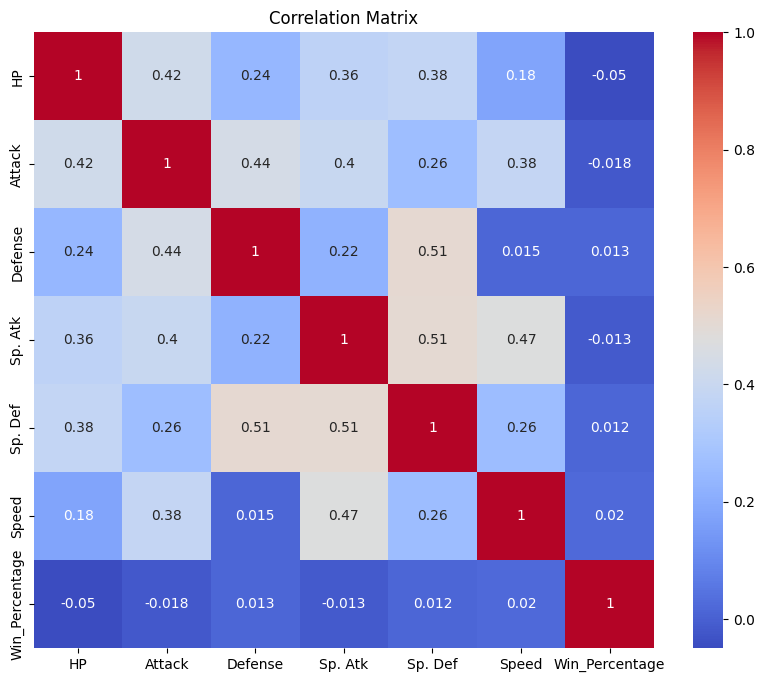

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric stats
stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']
corr_matrix = pokemon[stats].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

2.2 Pairplot for key stats vs. win percentage

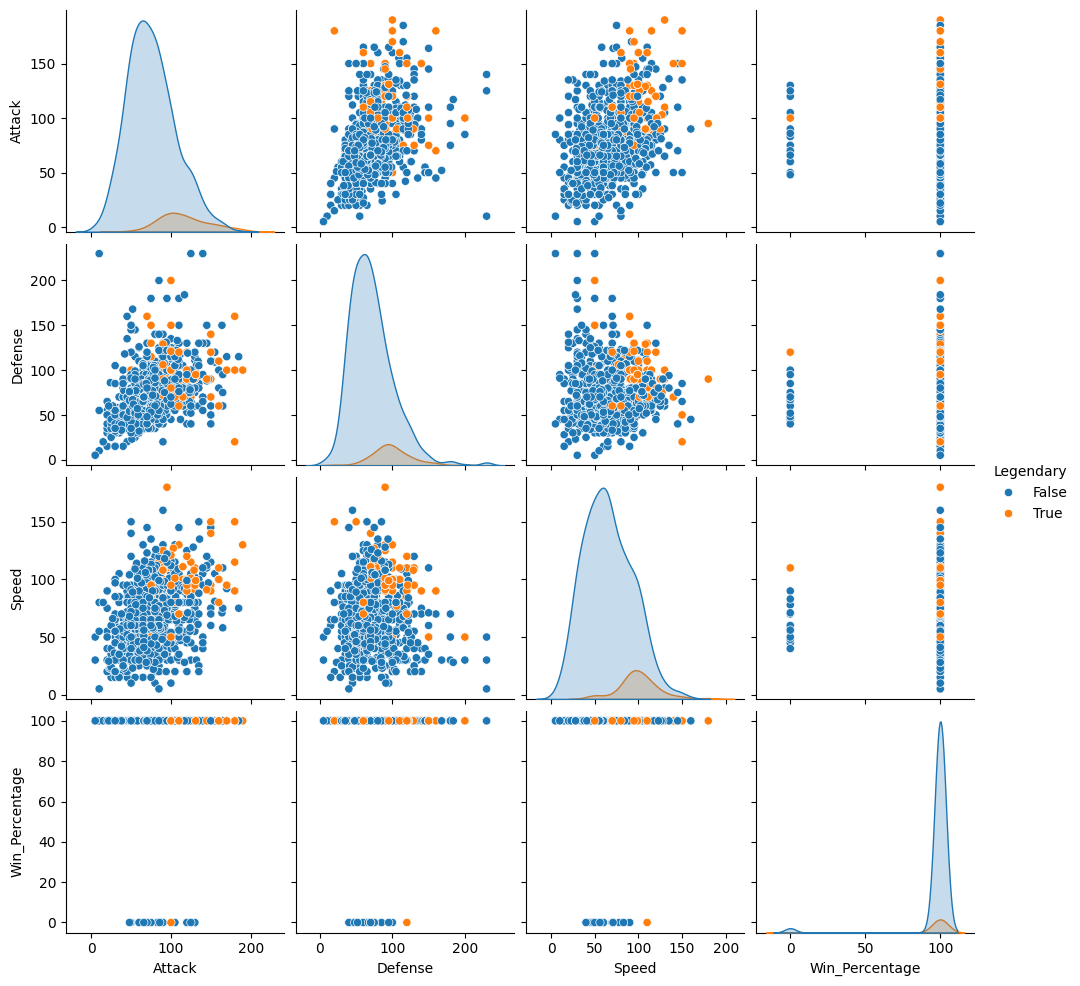

In [5]:
sns.pairplot(pokemon, vars=['Attack','Defense','Speed','Win_Percentage'], hue='Legendary')
plt.show()

2.3 Top 10 Pokemon by Win Percentage

In [6]:
top10 = pokemon.sort_values('Win_Percentage', ascending=False).head(10)
print(top10[['Name', 'Win_Percentage', 'Attack', 'Speed', 'HP']])

                       Name  Win_Percentage  Attack  Speed  HP
783    Pumpkaboo Super Size           100.0      66     41  59
782    Pumpkaboo Large Size           100.0      66     46  54
780  Pumpkaboo Average Size           100.0      66     51  49
779               Trevenant           100.0     110     56  85
778                Phantump           100.0      70     38  43
777                  Klefki           100.0      80     75  57
776                  Goodra           100.0     100     80  90
775                 Sliggoo           100.0      75     60  68
774                   Goomy           100.0      50     40  45
773                 Carbink           100.0      50     50  50


## Step 3: Machine Learning

3.1 Prepare features and target

In [7]:
from sklearn.model_selection import train_test_split

# Features: numeric stats
X = pokemon[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']]
y = pokemon['Win_Percentage']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3.2 Train models

#### Linear Regression

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression MAE: 3.788595745568423


#### Random Forest Regressor

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print("Random Forest MAE:", mae_rf)

Random Forest MAE: 4.89375


#### XGBoost Regressor

In [10]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
print("XGBoost MAE:", mae_xgb)

XGBoost MAE: 5.541825437545777


3.3 Compare Model Performance

In [11]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_rf, mae_xgb]
})
print(results)

               Model       MAE
0  Linear Regression  3.788596
1      Random Forest  4.893750
2            XGBoost  5.541825


## Step 4: Optional — Dimensionality Reduction with PCA

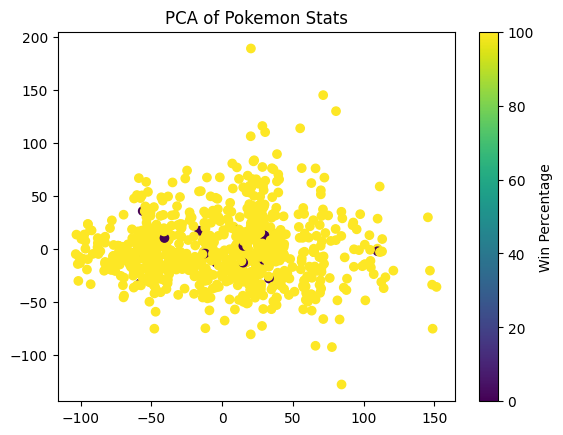

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.colorbar(label='Win Percentage')
plt.title("PCA of Pokemon Stats")
plt.show()